# PROYECTO FINAL MODULO 5: ENTRENAMIENTO DE MODELO DE MACHINE LEARNING PARA DETERMINAR SI UN PACIENTE SUFRE DE ANEMIA

## FUENTE : [DATOS ABIERTOS](https://www.datosabiertos.gob.pe/dataset/morbilidad-anemia)

### Autor: Mario Paucar Oscanoa

In [1]:
!pip install pyjanitor
import janitor

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATASET_PATH = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_ANEMIA.csv"
df_anemia = pd.read_csv(DATASET_PATH,sep = ";")
df_anemia.head(10)

<>:1: DeprecationWarning: invalid escape sequence '\C'
<>:1: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_7696\2802155508.py:1: DeprecationWarning: invalid escape sequence '\C'
  DATASET_PATH = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_ANEMIA.csv"


,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
0,40971314,2,A,M,NaN,20230522,D649,D,6203
1,39270343,4,A,M,1128.0,20211122,D509,D,10836
2,39270343,4,A,M,1128.0,20211129,D509,D,10836
3,39155787,3,A,F,1128.0,20210527,D509,D,10836
4,36178995,2,A,F,1299.0,20210215,D509,D,6079
5,38926264,4,A,M,1506.0,20211113,D509,D,7475
6,39141175,1,A,M,1128.0,20210220,D509,D,6856
7,40229751,2,A,M,1278.0,20221120,D509,D,4416
8,39603123,1,A,M,1278.0,20210428,D509,D,4416
9,39105165,1,A,M,1128.0,20210106,D509,D,10836


# EDA

In [4]:
df_anemia.shape

(1327924, 9)

In [5]:
df_anemia.dtypes

id_persona          int64
Edad                int64
Tipo_edad          object
Sexo               object
id_ubigeo         float64
Fecha_atencion      int64
Diagnostico        object
Tipo_Dx            object
id_eess             int64
dtype: object

# TRATAMIENTO DE NULOS

In [6]:
df_anemia.isnull().sum().sum()

10817

In [7]:
df_anemia.isnull().sum()

id_persona            0
Edad                  0
Tipo_edad             0
Sexo                  0
id_ubigeo         10817
Fecha_atencion        0
Diagnostico           0
Tipo_Dx               0
id_eess               0
dtype: int64

In [8]:
df_anemia.dropna(subset=['id_ubigeo'],inplace=True)
df_anemia.shape

(1317107, 9)

# TRATAMIENTO DE DUPLICADOS

In [9]:
df_anemia.duplicated().sum()

19287

In [10]:
df_anemia[df_anemia.duplicated()]

,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
329,38985611,1,A,F,26.0,20210716,D509,D,5081
369,38942468,1,A,M,42.0,20210627,D509,D,5183
610,38954543,2,A,F,42.0,20211210,D509,D,5180
612,38954543,2,A,F,42.0,20211110,D509,D,5180
827,39153550,2,A,F,26.0,20220329,D509,D,6977
...,...,...,...,...,...,...,...,...,...
1327513,35766370,2,A,F,1283.0,20210820,D509,D,5882
1327576,26591876,2,A,F,675.0,20211108,D509,D,4574
1327624,23789774,1,A,F,1288.0,20210309,D509,D,5995
1327878,33283345,4,A,M,1414.0,20240120,D509,D,5656


In [11]:
df_anemia.drop_duplicates(keep='first',inplace=True)
df_anemia.shape

(1297820, 9)

# ANALIZANDO VARIABLES

## ELIMINAMOS ID_PERSONA

In [12]:
df_anemia.drop(['id_persona'],axis=1,inplace=True)
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
1,4,A,M,1128.0,20211122,D509,D,10836
2,4,A,M,1128.0,20211129,D509,D,10836
3,3,A,F,1128.0,20210527,D509,D,10836
4,2,A,F,1299.0,20210215,D509,D,6079
5,4,A,M,1506.0,20211113,D509,D,7475
6,1,A,M,1128.0,20210220,D509,D,6856
7,2,A,M,1278.0,20221120,D509,D,4416
8,1,A,M,1278.0,20210428,D509,D,4416
9,1,A,M,1128.0,20210106,D509,D,10836
10,1,A,M,1128.0,20210107,D509,D,10836


# CONVERTIMOS DATA  DE EDAD A AÑOS

In [13]:
df_anemia.Tipo_edad.value_counts()

A    920953
M    375857
D      1010
Name: Tipo_edad, dtype: int64

In [14]:
df_anemia['edad_total'] = np.where(df_anemia['Tipo_edad'] == 'M', df_anemia['Edad'] / 12,
    np.where(df_anemia['Tipo_edad'] == 'D', df_anemia['Edad'] / 365, df_anemia['Edad'])
)
df_anemia[df_anemia['Tipo_edad']=='D'].head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total
1775,1,D,F,1477.0,20210106,D509,D,125,0.002740
4616,1,D,F,1128.0,20210531,D509,D,10836,0.002740
5149,20,D,M,994.0,20210608,D539,D,3364,0.054795
6450,6,D,F,1464.0,20210213,D509,D,212,0.016438
6694,1,D,M,774.0,20220225,D509,D,2435,0.002740
6740,24,D,F,1866.0,20210423,D509,D,5513,0.065753
7054,1,D,M,1460.0,20210805,D509,D,16,0.002740
7144,9,D,F,1274.0,20211204,D509,D,4432,0.024658
7177,17,D,F,1248.0,20220322,D509,D,4327,0.046575
7248,16,D,M,1484.0,20210308,D500,D,146,0.043836


# ANALIZAMOS ID_UBIGEO

In [15]:
df_anemia['id_ubigeo'].value_counts()

1312.0    33487
1283.0    20689
1290.0    13846
1863.0    13049
1323.0    13029
          ...  
1842.0        1
320.0         1
1841.0        1
190.0         1
1890.0        1
Name: id_ubigeo, Length: 1868, dtype: int64

In [16]:
PATH_UBIGEOS = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_UBIGEOS.csv"
df_ubigeos = pd.read_csv(PATH_UBIGEOS,sep=';')
df_ubigeos.head(10)

<>:1: DeprecationWarning: invalid escape sequence '\C'
<>:1: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_7696\1910342920.py:1: DeprecationWarning: invalid escape sequence '\C'
  PATH_UBIGEOS = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_UBIGEOS.csv"


,id_ubigeo,ubigeo_reniec,ubigeo_inei,departamento_inei,departamento,provincia_inei,provincia,distrito,region,macroregion_inei,macroregion_minsa,iso_3166_2,fips,superficie,altitud,latitud,longitud,Frontera
0,1,10101.0,10101,1,AMAZONAS,101,CHACHAPOYAS,CHACHAPOYAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,154.0,2338.0,-6.2294,-77.8728,NO
1,2,10102.0,10102,1,AMAZONAS,101,CHACHAPOYAS,ASUNCION,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,26.0,2823.0,-6.0325,-77.7108,NO
2,3,10103.0,10103,1,AMAZONAS,101,CHACHAPOYAS,BALSAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,357.0,859.0,-6.8358,-78.0197,NO
3,4,10104.0,10104,1,AMAZONAS,101,CHACHAPOYAS,CHETO,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,57.0,2143.0,-6.2556,-77.7008,NO
4,5,10105.0,10105,1,AMAZONAS,101,CHACHAPOYAS,CHILIQUIN,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,143.0,2677.0,-6.0783,-77.7375,NO
5,6,10106.0,10106,1,AMAZONAS,101,CHACHAPOYAS,CHUQUIBAMBA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,279.0,2803.0,-6.9350,-77.8542,NO
6,7,10107.0,10107,1,AMAZONAS,101,CHACHAPOYAS,GRANADA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,181.0,3041.0,-6.1064,-77.6286,NO
7,8,10108.0,10108,1,AMAZONAS,101,CHACHAPOYAS,HUANCAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,49.0,2591.0,-6.1736,-77.8644,NO
8,9,10109.0,10109,1,AMAZONAS,101,CHACHAPOYAS,LA JALCA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,380.0,2869.0,-6.4847,-77.8150,NO
9,10,10110.0,10110,1,AMAZONAS,101,CHACHAPOYAS,LEIMEBAMBA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,373.0,2226.0,-6.7075,-77.8039,NO


In [17]:
df_anemia_ubigeo = df_ubigeos[['id_ubigeo','departamento','superficie','altitud','latitud','longitud','Frontera']].copy()
df_anemia_ubigeo.head()

,id_ubigeo,departamento,superficie,altitud,latitud,longitud,Frontera
0,1,AMAZONAS,154.0,2338.0,-6.2294,-77.8728,NO
1,2,AMAZONAS,26.0,2823.0,-6.0325,-77.7108,NO
2,3,AMAZONAS,357.0,859.0,-6.8358,-78.0197,NO
3,4,AMAZONAS,57.0,2143.0,-6.2556,-77.7008,NO
4,5,AMAZONAS,143.0,2677.0,-6.0783,-77.7375,NO


In [18]:
df_anemia = df_anemia.merge(df_anemia_ubigeo,on='id_ubigeo',how='left')
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,superficie,altitud,latitud,longitud,Frontera
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO
1,4,A,M,1128.0,20211129,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO
2,3,A,F,1128.0,20210527,D509,D,10836,3.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO
3,2,A,F,1299.0,20210215,D509,D,6079,2.0,LIMA,180.0,12.0,-12.2747,-76.8703,NO
4,4,A,M,1506.0,20211113,D509,D,7475,4.0,MADRE DE DIOS,22219.0,204.0,-12.5936,-69.1767,SI
5,1,A,M,1128.0,20210220,D509,D,6856,1.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO
6,2,A,M,1278.0,20221120,D509,D,4416,2.0,LAMBAYEQUE,992.0,174.0,-6.2747,-79.6072,NO
7,1,A,M,1278.0,20210428,D509,D,4416,1.0,LAMBAYEQUE,992.0,174.0,-6.2747,-79.6072,NO
8,1,A,M,1128.0,20210106,D509,D,10836,1.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO
9,1,A,M,1128.0,20210107,D509,D,10836,1.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO


In [19]:
df_anemia['cie10'] = np.where(df_anemia['Diagnostico'].str.startswith(('D50','D53','D64')),1,0)

In [20]:
df_anemia.head(3)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,superficie,altitud,latitud,longitud,Frontera,cie10
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1
1,4,A,M,1128.0,20211129,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1
2,3,A,F,1128.0,20210527,D509,D,10836,3.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1


In [21]:
df_anemia['Fecha_atencion'] = df_anemia['Fecha_atencion'].astype(str)
df_anemia['mes'] = df_anemia['Fecha_atencion'].str[4:6]
df_anemia.head(1)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,superficie,altitud,latitud,longitud,Frontera,cie10,mes
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,11


In [22]:
df_anemia_processed = df_anemia.copy()
df_anemia_processed.rename(columns={'Sexo':'sexo','departamento':'dpto','edad_total':'edad','cie10':'anemia'},inplace=True)
df_anemia_processed.head(10)

,Edad,Tipo_edad,sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad,dpto,superficie,altitud,latitud,longitud,Frontera,anemia,mes
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,11
1,4,A,M,1128.0,20211129,D509,D,10836,4.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,11
2,3,A,F,1128.0,20210527,D509,D,10836,3.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,05
3,2,A,F,1299.0,20210215,D509,D,6079,2.0,LIMA,180.0,12.0,-12.2747,-76.8703,NO,1,02
4,4,A,M,1506.0,20211113,D509,D,7475,4.0,MADRE DE DIOS,22219.0,204.0,-12.5936,-69.1767,SI,1,11
5,1,A,M,1128.0,20210220,D509,D,6856,1.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,02
6,2,A,M,1278.0,20221120,D509,D,4416,2.0,LAMBAYEQUE,992.0,174.0,-6.2747,-79.6072,NO,1,11
7,1,A,M,1278.0,20210428,D509,D,4416,1.0,LAMBAYEQUE,992.0,174.0,-6.2747,-79.6072,NO,1,04
8,1,A,M,1128.0,20210106,D509,D,10836,1.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,01
9,1,A,M,1128.0,20210107,D509,D,10836,1.0,JUNIN,3679.0,816.0,-11.4283,-74.4889,NO,1,01


In [24]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


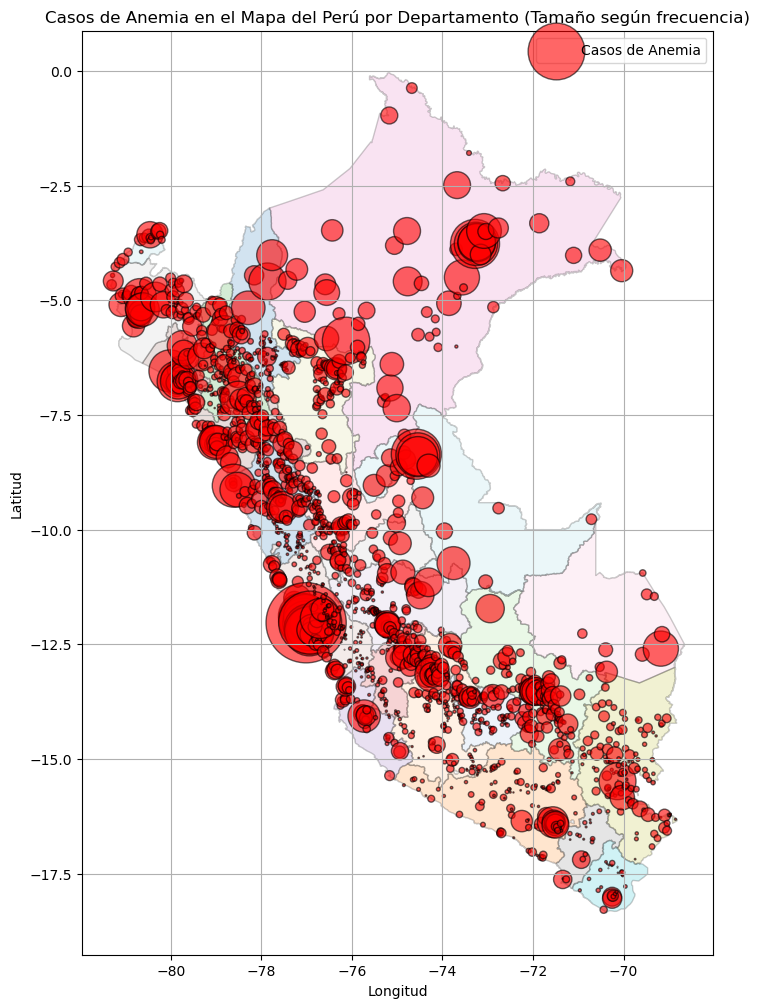

In [51]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del shapefile (usa raw string o doble backslash)
shapefile_path = r"D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\DEPARTAMENTOS.shp"

# Cargar shapefile
gdf_peru = gpd.read_file(shapefile_path)

# Filtrar solo casos con anemia
df_anemia = df_anemia_processed[df_anemia_processed["anemia"] == 1].copy()

# Verificar si las columnas de ubicación existen
if "longitud" not in df_anemia.columns or "latitud" not in df_anemia.columns:
    raise ValueError("Las columnas 'longitud' y 'latitud' no existen en df_anemia_processed.")

# Agrupar por (longitud, latitud) y contar casos
df_anemia_grouped = df_anemia.groupby(["longitud", "latitud"]).size().reset_index(name="casos")

# Crear el gráfico
fig, ax = plt.subplots(figsize=(10, 12))

# Dibujar los departamentos con colores diferenciados
gdf_peru.plot(ax=ax, cmap="tab20", legend=True, edgecolor="black", alpha=0.2)

# Graficar puntos de anemia en el mapa, aumentando el tamaño según el número de casos
ax.scatter(
    df_anemia_grouped["longitud"], 
    df_anemia_grouped["latitud"], 
    s=df_anemia_grouped["casos"] * 0.1,  # Escalar tamaño del punto
    color="red", 
    label="Casos de Anemia", 
    alpha=0.6, 
    edgecolors="black"
)

# Personalización del gráfico
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Casos de Anemia en el Mapa del Perú por Departamento (Tamaño según frecuencia)")
plt.legend()
plt.grid()

# Mostrar mapa
plt.show()

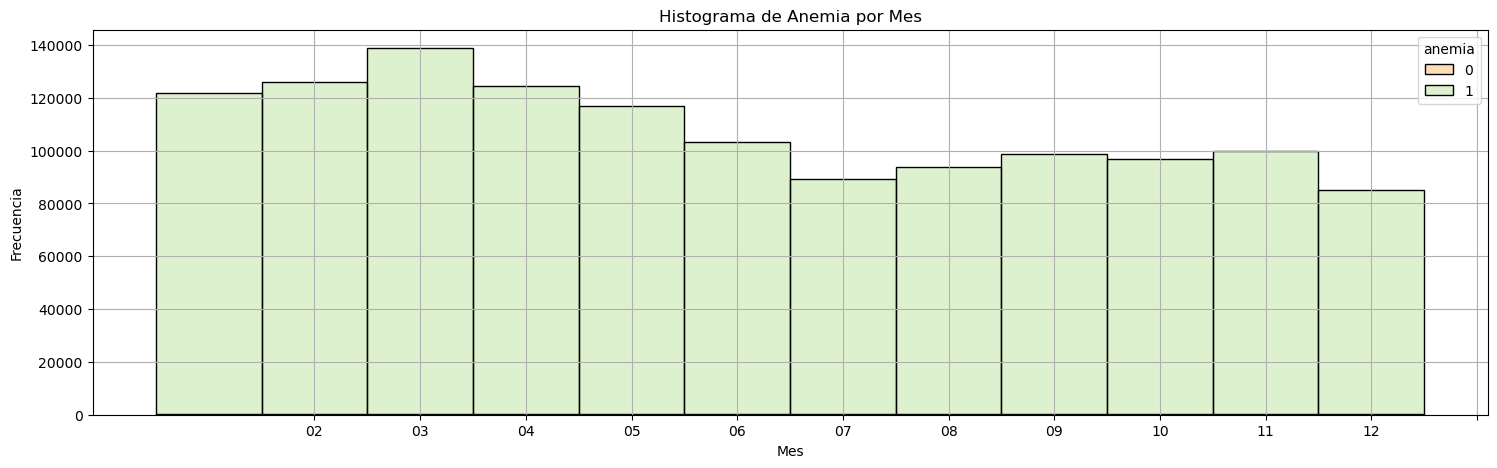

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# Ordenar los meses (asegurarse de que sean numéricos y estén en orden)
df_anemia_processed["mes"] = pd.Categorical(df_anemia_processed["mes"], 
                                            categories=sorted(df_anemia_processed["mes"].unique()), 
                                            ordered=True)

# Crear histograma separado por anemia
sns.histplot(data=df_anemia_processed, x="mes", hue="anemia", palette="Spectral", discrete=True)

# Personalización del gráfico
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.title("Histograma de Anemia por Mes")
plt.xticks(range(1, 13))  # Asegurar que se muestren los 12 meses
plt.grid(True)

# Mostrar gráfico
plt.show()

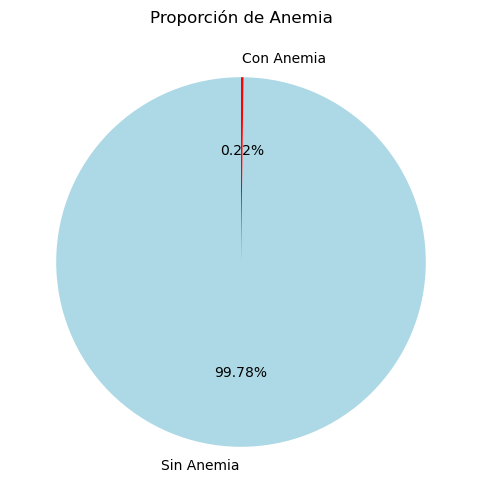

In [53]:
import matplotlib.pyplot as plt

# Contar casos con y sin anemia
conteo_anemia = df_anemia_processed["anemia"].value_counts()

# Etiquetas para el gráfico
labels = ["Sin Anemia", "Con Anemia"]

# Crear gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(conteo_anemia, labels=labels, autopct="%.2f%%", colors=["lightblue", "red"], startangle=90)

# Título y mostrar gráfico
plt.title("Proporción de Anemia")
plt.show()

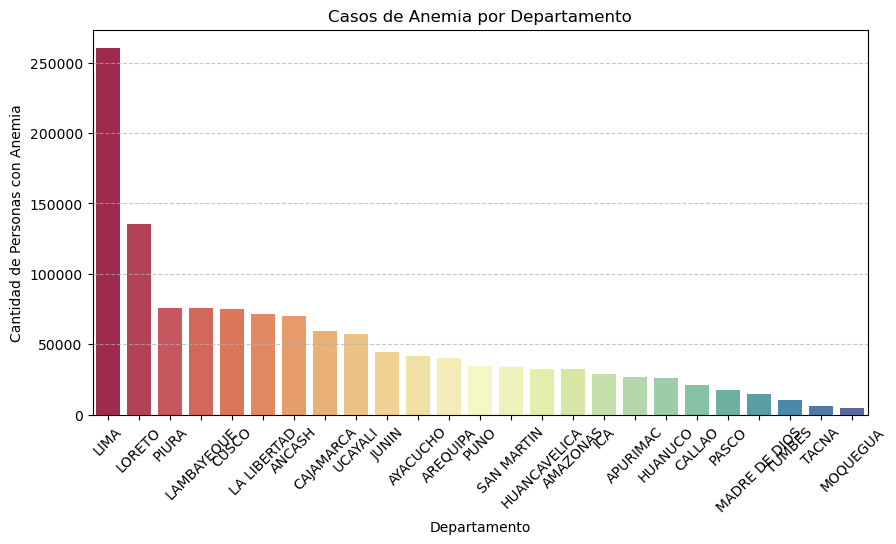

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo personas con anemia (asumiendo que 1 = tiene anemia)
df_anemia = df_anemia_processed[df_anemia_processed["anemia"] == 1]

# Contar casos de anemia por departamento
conteo_anemia_dpto = df_anemia["dpto"].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_anemia_dpto.index, y=conteo_anemia_dpto.values, palette="Spectral")

# Personalización del gráfico
plt.xlabel("Departamento")
plt.ylabel("Cantidad de Personas con Anemia")
plt.title("Casos de Anemia por Departamento")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor visibilidad
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()

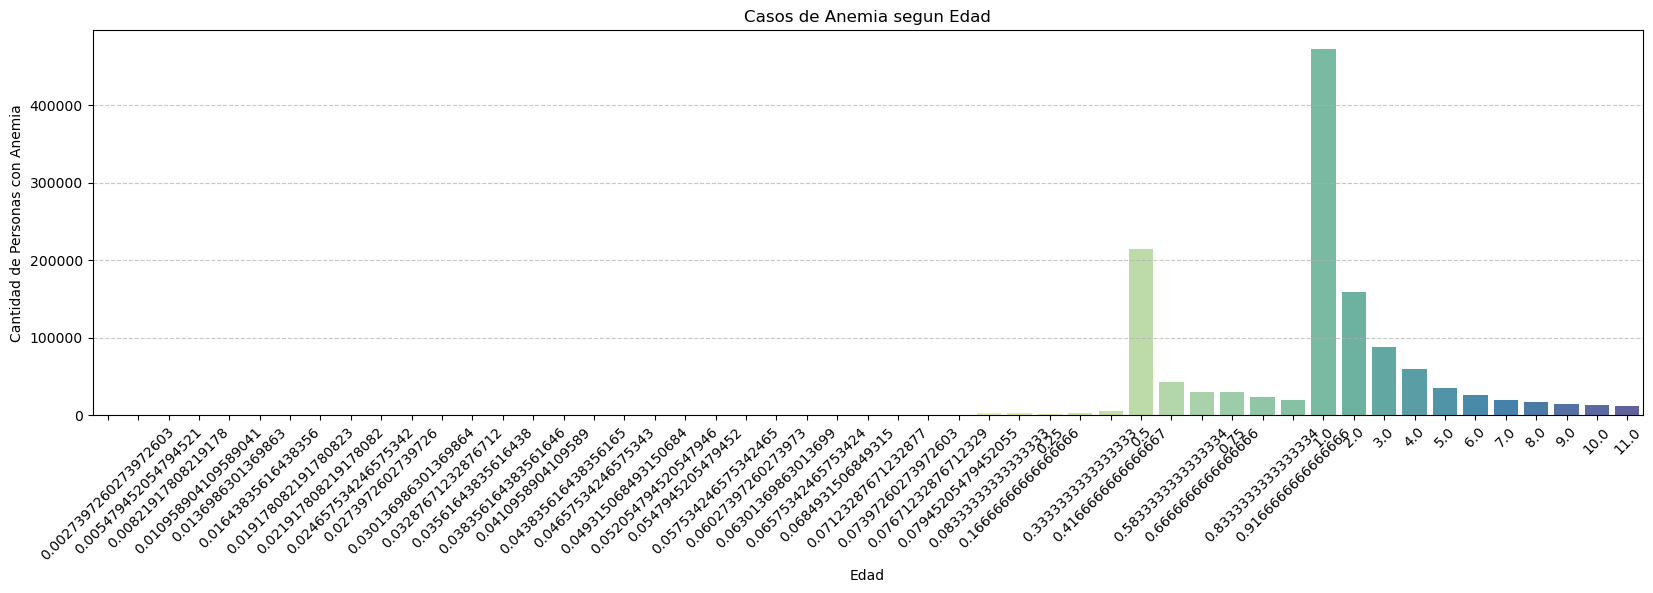

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo personas con anemia (asumiendo que 1 = tiene anemia)
df_anemia = df_anemia_processed[df_anemia_processed["anemia"] == 1]

# Contar casos de anemia por departamento
conteo_anemia_dpto = df_anemia["edad"].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(20, 5))
sns.barplot(x=conteo_anemia_dpto.index, y=conteo_anemia_dpto.values, palette="Spectral")

# Personalización del gráfico
plt.xlabel("Edad")
plt.ylabel("Cantidad de Personas con Anemia")
plt.title("Casos de Anemia segun Edad")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor visibilidad
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()

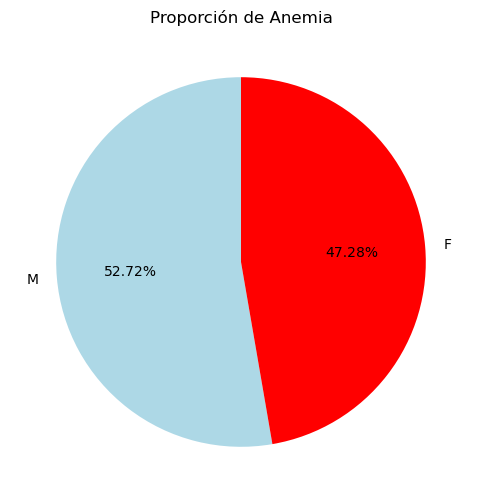

In [56]:
import matplotlib.pyplot as plt

# Contar casos con y sin anemia
conteo_anemia = df_anemia_processed["sexo"].value_counts()

# Etiquetas para el gráfico
labels = ["M", "F"]

# Crear gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(conteo_anemia, labels=labels, autopct="%.2f%%", colors=["lightblue", "red"], startangle=90)

# Título y mostrar gráfico
plt.title("Proporción de Anemia")
plt.show()

## Identificamos variables categóricas

In [57]:
categorical_columns = df_anemia_processed.select_dtypes(object).columns
categorical_columns

Index(['Tipo_edad', 'sexo', 'Fecha_atencion', 'Diagnostico', 'Tipo_Dx', 'dpto',
       'Frontera'],
      dtype='object')

## Creamos lista por tipo de codificación

In [58]:
for cc in categorical_columns:
  print("*"*50)
  print(df_anemia_processed[cc].value_counts())

**************************************************
A    920953
M    375857
D      1010
Name: Tipo_edad, dtype: int64
**************************************************
M    684186
F    613634
Name: sexo, dtype: int64
**************************************************
20221121    1793
20221114    1755
20220919    1745
20221010    1733
20221212    1732
            ... 
20211225     137
20231231     133
20240623     129
20240629      60
20240630       5
Name: Fecha_atencion, Length: 1277, dtype: int64
**************************************************
D509    1248531
D649      27278
D539       7103
D508       5973
D500       3257
D510       1113
D519        745
D648        593
D530        565
D529        537
D538        473
D501        359
D640        278
D643        180
D518        143
D520        129
D644        126
D532        110
D531         77
D513         72
D511         54
D641         38
D642         37
D528         32
D521         13
D512          4
Name: Diagnostico, dtype: int

In [59]:
ordinal_cols = ['sexo','mes','dpto']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['sexo', 'mes', 'dpto'] ['Tipo_edad', 'Tipo_Dx', 'Fecha_atencion', 'Frontera', 'Diagnostico']


## Creamos un transformer

In [60]:
import sklearn.compose
import sklearn.preprocessing
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['sexo', 'mes', 'dpto']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['Tipo_edad', 'Tipo_Dx', 'Fecha_atencion',
                                  'Frontera', 'Diagnostico'])])

## Aplicamos el transformer a la variable categórica

In [61]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_anemia_processed),
        columns = transformer.get_feature_names_out(),
        index=df_anemia_processed.index
    )
)

data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

ValueError: Shape of passed values is (1297820, 1), indices imply (1297820, 1321)

In [ ]:
corr_matrix = data_transformed_df.corr()
corr_class = corr_matrix['anemia']
corr_class.sort_values(ascending=False)

In [ ]:
sns.heatmap(
    data=corr_class.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [ ]:
corr_filtered = corr_class[corr_class > 0.001]
cols = corr_filtered.index.tolist()
cols

In [ ]:
X = data_transformed_df.drop(columns=['anemia','mes','dpto'])
y = data_transformed_df['anemia']

In [ ]:
display(X)

## Aplicando Regresión Logística

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

## Aplicamos Árboles de Decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import graphviz

tree1 = DecisionTreeClassifier()
tree1.fit(X_train,y_train)
y_pred = tree1.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy TREE 1 : {accuracy}')

tree.plot_tree(tree1)

In [ ]:
import graphviz
dot_data = tree.export_graphviz(tree1, out_file=None, 
                     #feature_names=iris.feature_names,  
                     #class_names=iris.target_names,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Datos (usamos X, y de tu dataset)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_scores = []
val_scores = []
max_depths = range(1, 50)  # Profundidades de 1 a 20

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Evaluamos en los conjuntos de entrenamiento y validación
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    train_scores.append(train_acc)
    val_scores.append(val_acc)

# Graficamos las curvas de accuracy
plt.figure(figsize=(10, 5))
plt.plot(max_depths, train_scores, label="Entrenamiento", marker='o')
plt.plot(max_depths, val_scores, label="Validación", marker='s')
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Detección de Overfitting en Árbol de Decisión")
plt.legend()
plt.grid(True)
plt.show()